# Aspheric Collimator

The first step in this design is to construct a model of the LED collimator. In a later step, I will perfom a Monte Carlo ray trace to determine the irradiance and intensity profiles at different axial distances from the collimator.

In [1]:
import matplotlib.pyplot as plt
from optiland import optic, optimization

## Off-the-shelf Parts

After speaking with a Thorlabs technician, my colleague purchased the following hardware to construct the collimator:

- A M450LP2 2W blue LED <https://www.thorlabs.com/item/M450LP2>
- A SM1U25-A adjustable collimation adapter <https://www.thorlabs.com/item/SM1U25-A>

The LED has rectangular dimensions of 1.5 mm x 1.5 mm.

The collimator uses a [ACL2520U-A aspheric lens](https://www.meetoptics.com/lenses/aspheric/condenser-lens/s/thorlabs/p/ACL2520U-A), which has a focal length of 20.1 mm and numerical aperture of 0.6.

I first construct the model of the LED and asphere. I use two object height fields: one on-axis and another at 1.06 mm, which is the half-diagonal of the LED emitter surface.

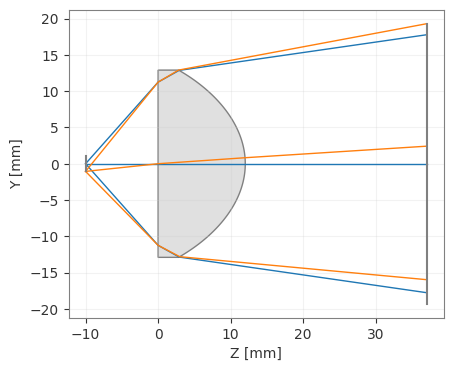

In [2]:
lens = optic.Optic()

lens.add_surface(index=0, thickness=10.0, material="Air")   # Air gap before lens
lens.add_surface(index=1, thickness=12.0163, material="B270", is_stop=True)  # Planar surface
lens.add_surface(
    index=2,
    thickness=25.0,
    material="Air",
    radius=-10.462,
    conic=-0.6265,
    surface_type="even_asphere",
    coefficients=[0.0, 1.5e-5]  # Aspheric surface
)
lens.add_surface(index=3)

lens.set_aperture("float_by_stop_size", 22.5)

lens.set_field_type(field_type="object_height")
lens.add_field(y=0.0)
lens.add_field(y=-1.06)

lens.add_wavelength(0.45, is_primary=True)
lens.draw(num_rays=3)
plt.show()

## Collimate the LED

The diverging rays after the lens in the sketch above indicate that the LED is not collimated at this distance from the lens.

To address this (at least initially), I set up an optimization problem to minimize the direction cosines of the rays in the y-direction for the on-axis field. This uses the `real_M` operand and treats the thickness of the first (object) surface as the variable.

In [3]:
problem = optimization.OptimizationProblem()

# Collimate rays from an on-axis point through different pupil coordinates
for pupil_coordinate in [0.0, 0.7, 1.0]:
    input_data = {
        "optic": lens,
        "surface_number": -1,
        "Hx": 0.0,
        "Hy": 0.0,
        "Px": 0.0,
        "Py": pupil_coordinate,
        "wavelength": 0.45,
    }
    problem.add_operand(operand_type="real_M", target=0.0, weight=1, input_data=input_data)  # Minimize y direction cosines

problem.add_variable(lens, "thickness", surface_number=0, min_val=10.0, max_val=20.0)
problem.info()


╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │              0.0345703 │                 0 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═════════╪═════════╪════════════════╡
│  0 │ real M         │        0 │              │              │        1 │   0     │   0     │           0    │
│  1 │ real M         │        0 │              │              │        1 │   0.119 │   0.119 │          41.23 │
│  2 │ real M         │        0 │              │              │        1 │   0.143 │   0.143 │          58.77 │
╘════╧════════════════╧══════════╧══════════════╧═════════════

I use the default optimizer because I don't see this problem as requiring anything special.

In [4]:
optimizer = optimization.OptimizerGeneric(problem)
optimizer.optimize()
problem.info()

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │            2.11412e-05 │           99.9388 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═════════╪═════════╪════════════════╡
│  0 │ real M         │        0 │              │              │        1 │   0     │   0     │            0   │
│  1 │ real M         │        0 │              │              │        1 │   0.004 │   0.004 │           71.1 │
│  2 │ real M         │        0 │              │              │        1 │  -0.002 │  -0.002 │           28.9 │
╘════╧════════════════╧══════════╧══════════════╧═════════════

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

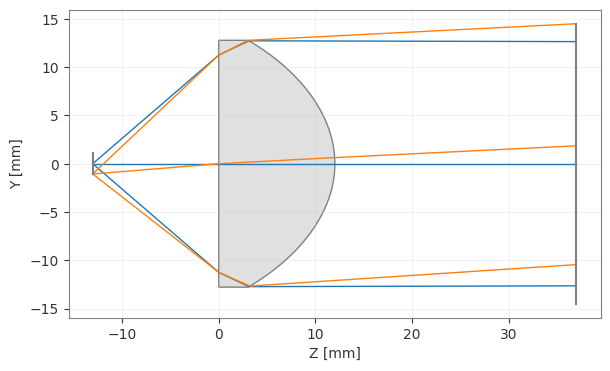

In [5]:
lens.draw(num_rays=3)

You can see that the lens now lies at a distance of about 13 mm from the LED surface.

As expected, the rays from the on-axis field are now approximately parallel to the axis.